<a href="https://colab.research.google.com/github/Desh-Deepak1/Colab-Projects/blob/main/NVDA_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [ ]:
warnings.filterwarnings('ignore')

# **Import NVIDIA Data**

In [ ]:
import yfinance as yf
import pandas as pd

print("Data fetch ho raha hai... Isme thoda time lag sakta hai.")
nvda_data = yf.download("NVDA", period="max")

if isinstance(nvda_data.columns, pd.MultiIndex):
    nvda_data.columns = nvda_data.columns.get_level_values(0)

nvda_data.reset_index(inplace=True)

columns_order = ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

available_columns = [col for col in columns_order if col in nvda_data.columns]
nvda_data = nvda_data[available_columns]


csv_filename = "nvidia.csv"
nvda_data.to_csv(csv_filename, index=False)

print(f"Data successfully '{csv_filename}' naam se save ho gaya hai!")
print(f"CSV Columns: {', '.join(available_columns)}")

Data fetch ho raha hai... Isme thoda time lag sakta hai.


[*********************100%***********************]  1 of 1 completed

Data successfully 'nvidia.csv' naam se save ho gaya hai!
CSV Columns: Date, Open, High, Low, Close, Volume


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Sample Data**

In [ ]:
df = pd.read_csv("/content/nvidia.csv")

In [ ]:
df.head(10)

,Date,Open,High,Low,Close,Volume
0,1999-01-22,0.040109,0.044765,0.035573,0.037603,2714688000
1,1999-01-25,0.040587,0.042019,0.037603,0.041542,510480000
2,1999-01-26,0.042019,0.042855,0.037722,0.038319,343200000
3,1999-01-27,0.038438,0.039393,0.036289,0.038200,244368000
4,1999-01-28,0.038200,0.038438,0.037841,0.038080,227520000
5,1999-01-29,0.038080,0.038200,0.036289,0.036289,244032000
6,1999-02-01,0.036289,0.037244,0.036289,0.037006,154704000
7,1999-02-02,0.036289,0.037244,0.033067,0.034141,264096000
8,1999-02-03,0.033663,0.035335,0.033424,0.034857,75120000
9,1999-02-04,0.035335,0.037722,0.034857,0.036767,181920000


In [ ]:
df.tail(10)

,Date,Open,High,Low,Close,Volume
6819,2026-03-04,180.430240,184.690004,180.050256,183.030090,177731200
6820,2026-03-05,181.160197,184.050040,177.870382,183.330078,198779700
6821,2026-03-06,179.830259,182.750099,176.810433,177.810379,189021900
6822,2026-03-09,176.820429,182.900102,175.550494,182.640106,177213600
6823,2026-03-10,182.390128,186.429918,182.000149,184.760010,179118500
6824,2026-03-11,185.910004,187.619995,184.449997,186.029999,145280400
6825,2026-03-12,184.050003,184.940002,181.750000,183.139999,155762700
6826,2026-03-13,184.919998,186.089996,179.940002,180.250000,160988400
6827,2026-03-16,182.970001,188.880005,181.410004,183.220001,216616600
6828,2026-03-17,185.050003,185.399994,181.680405,181.940002,84451020


**Size of data**

In [ ]:
print("Size of Data:", df.shape)

Size of Data: (6829, 6)


**Field Info**

In [ ]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')

**Data Type**

In [ ]:
df.dtypes

,0
Date,object
Open,float64
High,float64
Low,float64
Close,float64
Volume,int64


#**Data Cleaning**

In [ ]:
print(df['Date'].unique())

['1999-01-22' '1999-01-25' '1999-01-26' ... '2026-03-13' '2026-03-16'
 '2026-03-17']


## **BUSINESS REQURIMENTS**

# **Data Perpration**

In [ ]:
sns.set_theme(style="whitegrid")


df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

df['Daily_Return_%'] = df['Close'].pct_change() * 100
df['Cumulative_Return'] = (1 + df['Daily_Return_%'] / 100).cumprod()
df['50_SMA'] = df['Close'].rolling(window=50).mean()
df['200_SMA'] = df['Close'].rolling(window=200).mean()

print("Data Ready for Visualization!")

Data Ready for Visualization!


# ***1.Long-Term Wealth Creation***

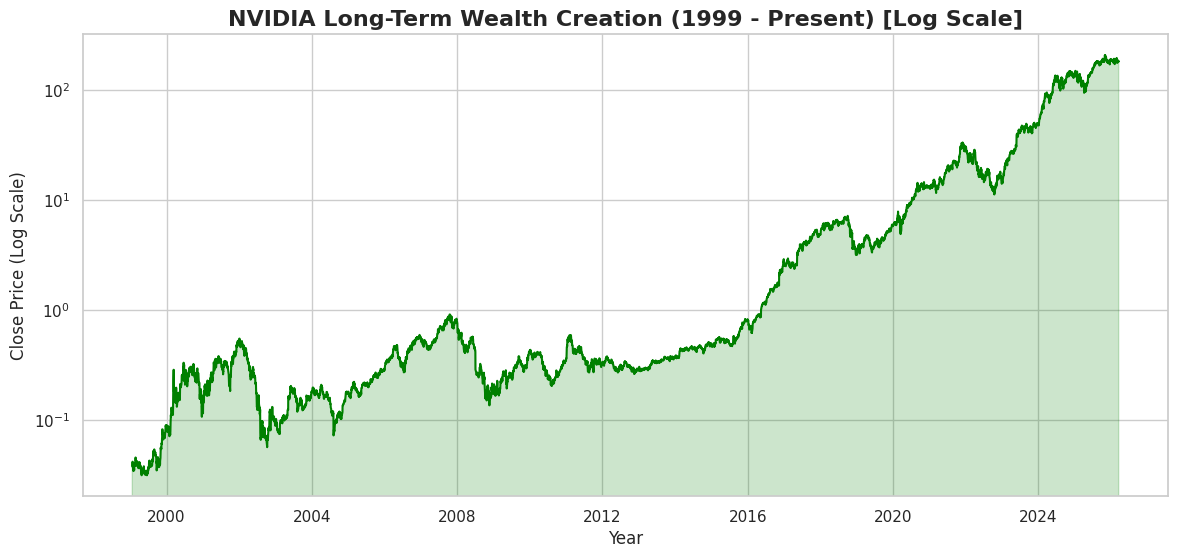

In [ ]:
plt.figure(figsize=(14, 6))


plt.plot(df.index, df['Close'], color='green', linewidth=1.5)
plt.yscale('log')
plt.title("NVIDIA Long-Term Wealth Creation (1999 - Present) [Log Scale]", fontsize=16, fontweight='bold')
plt.xlabel("Year", fontsize=12)
plt.ylabel("Close Price (Log Scale)", fontsize=12)
plt.fill_between(df.index, df['Close'], color='green', alpha=0.2)

plt.show()

# ***2. Trend Analysis (Major Events & Crises)***

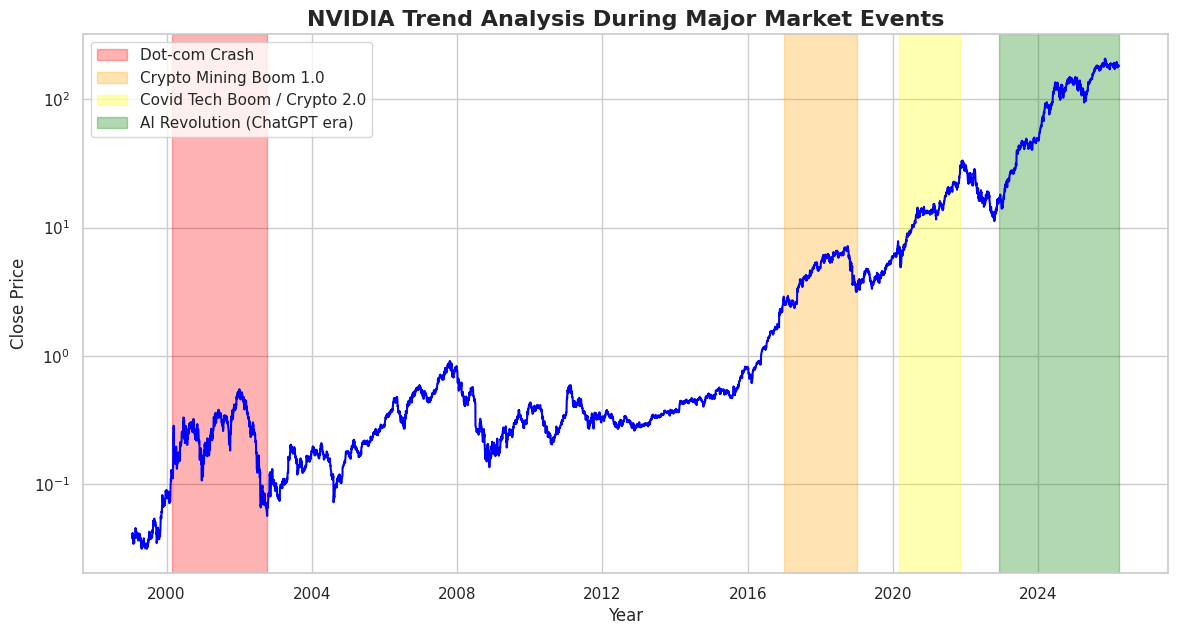

In [ ]:
plt.figure(figsize=(14, 7))
plt.plot(df.index, df['Close'], color='blue', linewidth=1.5)
plt.yscale('log')


plt.axvspan('2000-03-01', '2002-10-09', color='red', alpha=0.3, label='Dot-com Crash')
plt.axvspan('2017-01-01', '2018-12-31', color='orange', alpha=0.3, label='Crypto Mining Boom 1.0')
plt.axvspan('2020-03-01', '2021-11-01', color='yellow', alpha=0.3, label='Covid Tech Boom / Crypto 2.0')
plt.axvspan('2022-11-30', df.index[-1].strftime('%Y-%m-%d'), color='green', alpha=0.3, label='AI Revolution (ChatGPT era)')

plt.title("NVIDIA Trend Analysis During Major Market Events", fontsize=16, fontweight='bold')
plt.xlabel("Year", fontsize=12)
plt.ylabel("Close Price", fontsize=12)
plt.legend(loc='upper left')

plt.show()

# ***3.Risk & Volatility Assessment***

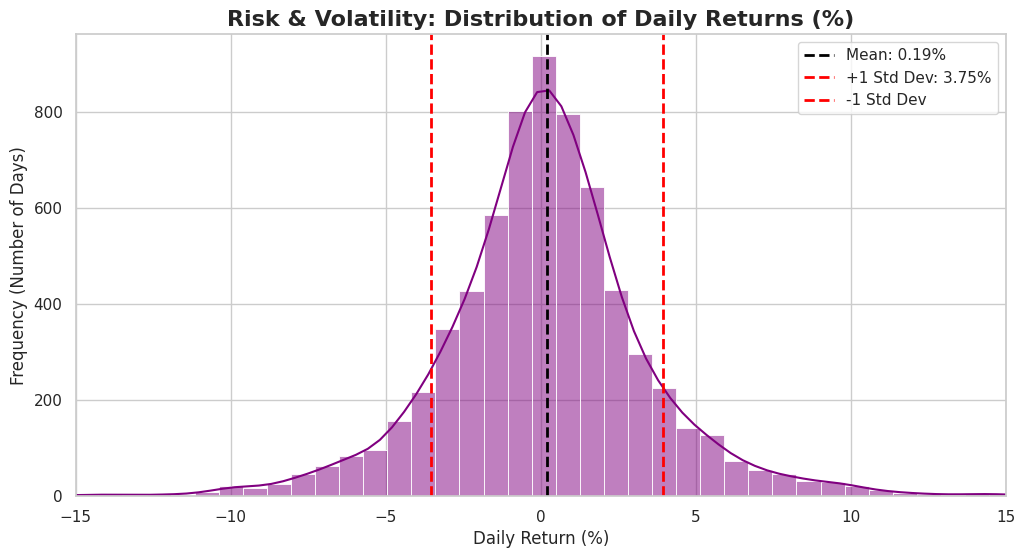

In [ ]:
plt.figure(figsize=(12, 6))


returns_data = df['Daily_Return_%'].dropna()

sns.histplot(returns_data, bins=100, kde=True, color='purple')

mean_return = returns_data.mean()
std_dev = returns_data.std()

plt.axvline(mean_return, color='black', linestyle='dashed', linewidth=2, label=f'Mean: {mean_return:.2f}%')
plt.axvline(mean_return + std_dev, color='red', linestyle='dashed', linewidth=2, label=f'+1 Std Dev: {std_dev:.2f}%')
plt.axvline(mean_return - std_dev, color='red', linestyle='dashed', linewidth=2, label=f'-1 Std Dev')

plt.xlim(-15, 15)
plt.title("Risk & Volatility: Distribution of Daily Returns (%)", fontsize=16, fontweight='bold')
plt.xlabel("Daily Return (%)", fontsize=12)
plt.ylabel("Frequency (Number of Days)", fontsize=12)
plt.legend()

plt.show()

# ***4. Liquidity & Market Interest (Volume Analysis)***

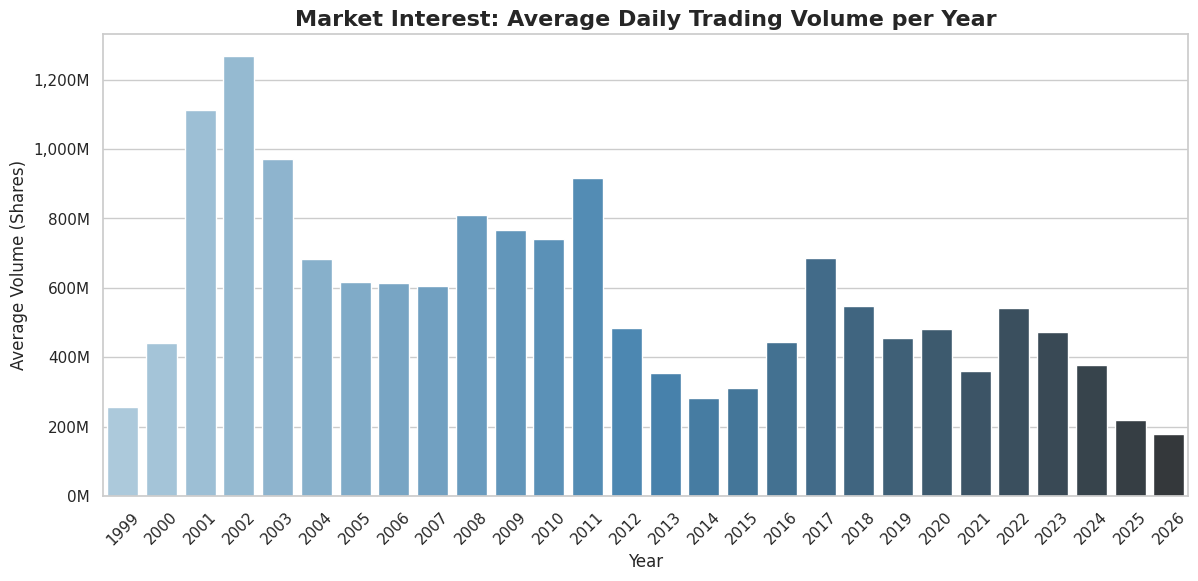

In [ ]:
df_yearly_vol = df['Volume'].resample('Y').mean()

plt.figure(figsize=(14, 6))
sns.barplot(x=df_yearly_vol.index.year, y=df_yearly_vol.values, palette='Blues_d')

plt.title("Market Interest: Average Daily Trading Volume per Year", fontsize=16, fontweight='bold')
plt.xlabel("Year", fontsize=12)
plt.ylabel("Average Volume (Shares)", fontsize=12)
plt.xticks(rotation=45)

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}M".format(int(x/1e6))))

plt.show()

# ***5. Future Forecasting & Momentum (Moving Averages)***

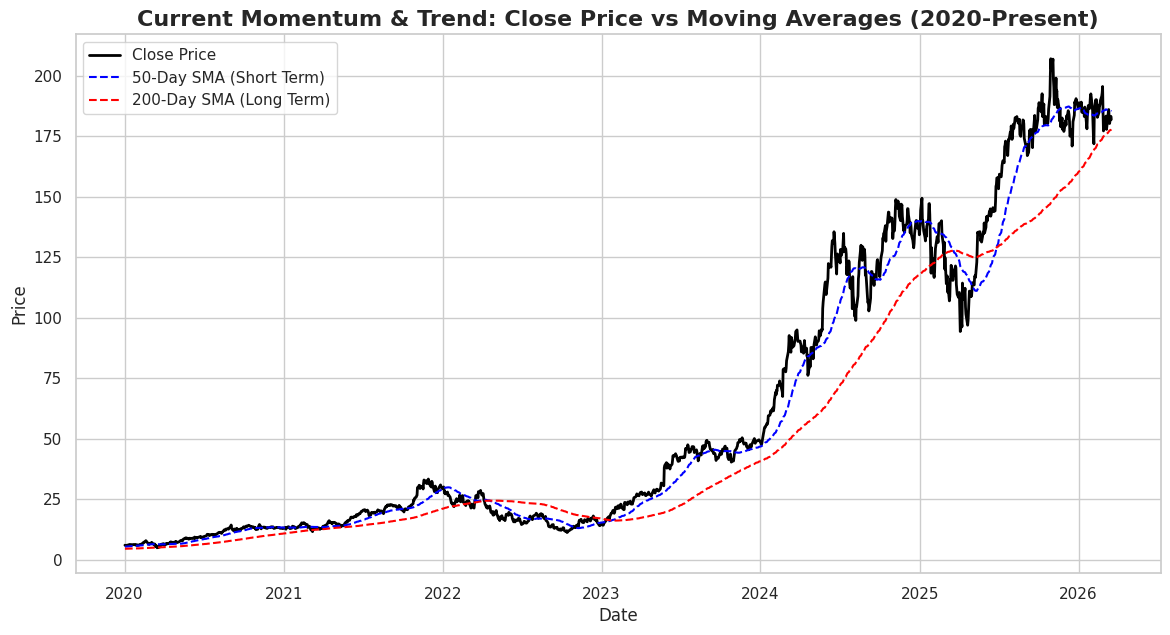

In [ ]:
recent_df = df[df.index >= '2020-01-01']

plt.figure(figsize=(14, 7))

plt.plot(recent_df.index, recent_df['Close'], label='Close Price', color='black', linewidth=2)
plt.plot(recent_df.index, recent_df['50_SMA'], label='50-Day SMA (Short Term)', color='blue', linestyle='--')
plt.plot(recent_df.index, recent_df['200_SMA'], label='200-Day SMA (Long Term)', color='red', linestyle='--')

plt.title("Current Momentum & Trend: Close Price vs Moving Averages (2020-Present)", fontsize=16, fontweight='bold')
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price", fontsize=12)
plt.legend()

plt.show()

# **KPI CALCULATIONS**

# ***1. Calculate All KPIs & Create Dashboard Cards***

In [ ]:
current_price = df['Close'].iloc[-1]
start_price = df['Close'].iloc[0]

ath = df['High'].max()
atl = df['Low'].min()

# Total ROI
total_roi = ((current_price - start_price) / start_price) * 100

# CAGR (Compound Annual Growth Rate)
years = (df.index[-1] - df.index[0]).days / 365.25
cagr = ((current_price / start_price) ** (1 / years) - 1) * 100

# YTD (Year-to-Date) Return
current_year = df.index[-1].year
ytd_data = df[df.index.year == current_year]
if not ytd_data.empty:
    ytd_start_price = ytd_data['Close'].iloc[0]
    ytd_return = ((current_price - ytd_start_price) / ytd_start_price) * 100
else:
    ytd_return = 0

# Average Daily Volume (Overall)
avg_volume = df['Volume'].mean()

# Maximum Drawdown (Top se kitna gira)
rolling_max = df['Close'].cummax()
drawdown = (df['Close'] - rolling_max) / rolling_max * 100
max_drawdown = drawdown.min()

# --- 2. PLOTLY KPI DASHBOARD (TOP CARDS) ---

# Create a 2x4 grid for our KPI indicators
fig = make_subplots(
    rows=2, cols=4,
    specs=[[{'type': 'indicator'}, {'type': 'indicator'}, {'type': 'indicator'}, {'type': 'indicator'}],
           [{'type': 'indicator'}, {'type': 'indicator'}, {'type': 'indicator'}, {'type': 'indicator'}]]
)

# 1. Current Price
fig.add_trace(go.Indicator(
    mode="number+delta", value=current_price, title={"text": "Current Price (USD)"},
    delta={'reference': start_price, 'relative': True, 'position': "bottom"},
    number={'prefix': "$"}), row=1, col=1)

# 2. Total ROI
fig.add_trace(go.Indicator(
    mode="number", value=total_roi, title={"text": "Total Return (ROI)"},
    number={'suffix': "%", 'valueformat': '.2f'}), row=1, col=2)

# 3. CAGR
fig.add_trace(go.Indicator(
    mode="number", value=cagr, title={"text": "CAGR (Yearly Growth)"},
    number={'suffix': "%", 'valueformat': '.2f'}), row=1, col=3)

# 4. YTD Return
fig.add_trace(go.Indicator(
    mode="number", value=ytd_return, title={"text": f"YTD Return ({current_year})"},
    number={'suffix': "%", 'valueformat': '.2f'}), row=1, col=4)

# 5. All-Time High (ATH)
fig.add_trace(go.Indicator(
    mode="number", value=ath, title={"text": "All-Time High (ATH)"},
    number={'prefix': "$", 'valueformat': '.2f'}), row=2, col=1)

# 6. All-Time Low (ATL)
fig.add_trace(go.Indicator(
    mode="number", value=atl, title={"text": "All-Time Low (ATL)"},
    number={'prefix': "$", 'valueformat': '.4f'}), row=2, col=2)

# 7. Average Volume
fig.add_trace(go.Indicator(
    mode="number", value=avg_volume, title={"text": "Avg Daily Volume"},
    number={'suffix': "M", 'valueformat': '.2s'}), row=2, col=3)

# 8. Max Drawdown
fig.add_trace(go.Indicator(
    mode="number", value=max_drawdown, title={"text": "Max Drawdown (Risk)"},
    number={'suffix': "%", 'valueformat': '.2f'},
    domain={'x': [0, 1], 'y': [0, 1]}), row=2, col=4) # Custom domain for red color can be added

# Update layout to look like a clean dashboard
fig.update_layout(
    title={'text': "NVIDIA (NVDA) Executive KPI Scorecard", 'y':0.95, 'x':0.5, 'xanchor': 'center', 'yanchor': 'top', 'font': {'size': 24, 'color': 'darkblue'}},
    height=500, margin=dict(l=20, r=20, t=100, b=20),
    paper_bgcolor="ghostwhite"
)

fig.show()

# ***2. Maximum Drawdown Visualization (Underwater Chart)***

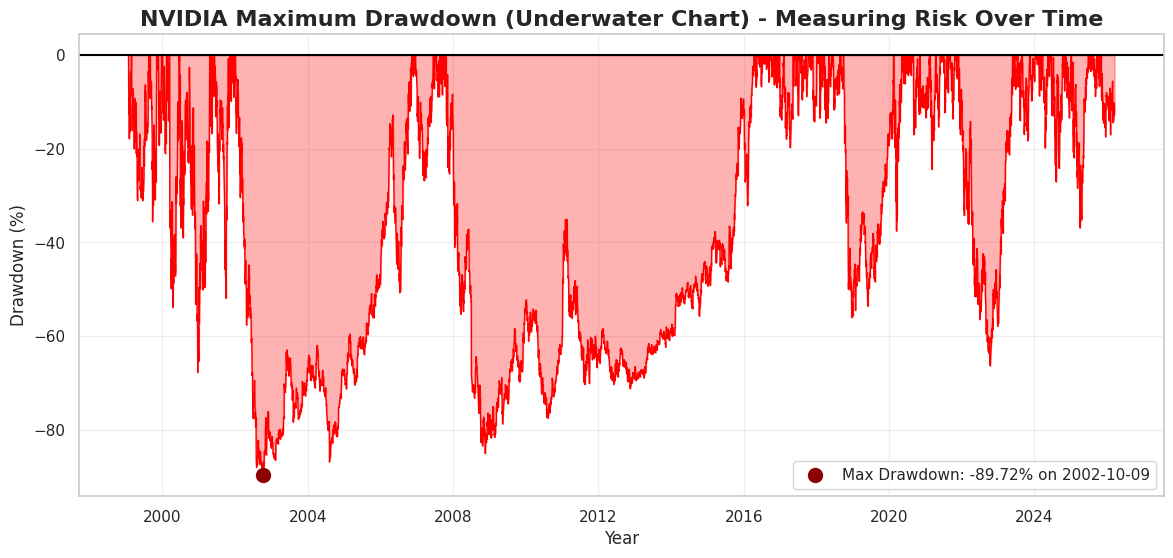

In [ ]:
plt.figure(figsize=(14, 6))

# Plot the drawdown percentage
plt.plot(drawdown.index, drawdown, color='red', linewidth=1)

# Fill the area below 0 to make it look like an "underwater" chart
plt.fill_between(drawdown.index, drawdown, 0, color='red', alpha=0.3)

# Highlight the absolute Maximum Drawdown point
max_drawdown_date = drawdown.idxmin()
max_drawdown_value = drawdown.min()

plt.scatter(max_drawdown_date, max_drawdown_value, color='darkred', s=100, zorder=5, label=f'Max Drawdown: {max_drawdown_value:.2f}% on {max_drawdown_date.date()}')

plt.title("NVIDIA Maximum Drawdown (Underwater Chart) - Measuring Risk Over Time", fontsize=16, fontweight='bold')
plt.xlabel("Year", fontsize=12)
plt.ylabel("Drawdown (%)", fontsize=12)
plt.axhline(0, color='black', linewidth=1.5)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

plt.show()